# Pairwise-SSP KS p-value maps at fixed GWL

**Pixel-level distributional path-independence test.** At a fixed global warming
level (GWL2.0), compare the daily near-surface T distribution under **SSP3-7.0
(the RAMIP reference)** against each other SSP, at every grid cell, with a
two-sample Kolmogorov–Smirnov test. Map the p-values.

*If* regional climate at a GWL is independent of the SSP pathway that reached it
(the BCD-ME Fig 2 claim, but for the full daily distribution rather than the
20-yr mean), the two distributions match and p is high. Low-p pixels mark where
path-independence **breaks** — expected where aerosol forcing differs most
(E/S Asia), the RAMIP hypothesis.

**Provenance of methods (audit):**
- KS comparison design and the p-value map follow the authors' `diag_qdm.ipynb`;
  the per-pixel scipy loop is replaced by a batched numpy KS (`ks_fast`, ~9×,
  validated against scipy: D exact, asymptotic p rtol < 1e-4).
- **Aggregation across runs = authors' convention** (`diag_qdm`): the **0.01
  quantile of p across matched runs**, plotted linear 0–1.
- *Comparison* is new: authors' `diag_qdm` KS-tests ESM **vs reanalysis**; here
  we KS **ssp370 vs other SSP** at fixed GWL. Authors' Fig 2 tests
  path-independence on the regional *mean*; this tests the full pixel
  *distribution*.
- Data via ArrayLake (`ClimateUncertaintyLab/bcd_me_qdm`).

**Design (multi-run):** ALL matched runs per model per pair (same
initial-condition member under both SSPs, so only forcing differs):
CanESM5 15 (p1+p2 physics), MPI-ESM1-2-LR 10, MIROC6 3 (ssp370 is its
bottleneck). IPSL-CM6A-LR dropped: `tas` never populated in the bcd_me_qdm repo
(all-NaN everywhere; `has_data` flags there unreliable — verified 2026-07-01).

Caveats: KS at N=7300 daily samples is overpowered — read spatial pattern, not
absolute p. Grid includes ocean (rejects far more than land); report land-only
stats. Single-run land fractions p<0.05 for reference: CanESM5 43–46%,
MPI 60–64%, MIROC6 75%.

In [1]:
import os, re, numpy as np, xarray as xr
import arraylake, zarr, regionmask
from scipy import stats as sstats
from scipy import special as sspecial
from matplotlib import pyplot as plt
import matplotlib as mpl
from cartopy import crs as ccrs
import cmocean

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
from funcs_support import get_params
dir_list = get_params()

# n_workers: set to the cores you requested. One map ~= 74 core-seconds (ks_fast).
N_WORKERS = int(os.environ.get('KS_NWORKERS', '16'))

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Distributed cluster (true parallelism; KS is python-level so needs processes)
from dask.distributed import Client, LocalCluster
client = Client(LocalCluster(n_workers=N_WORKERS, threads_per_worker=1,
                             processes=True, memory_limit='8GB'))
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 16
Total threads: 16,Total memory: 119.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33101,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42875,Total threads: 1
Dashboard: http://127.0.0.1:43327/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:43455,


In [3]:
# Parameters
VAR    = 'tas'
GWL    = 2.0
ANCHOR = 'ssp370'                 # RAMIP reference scenario
OTHERS = ['ssp245', 'ssp585']     # BCD-ME has no ssp126
PROJ   = 'ERA5'                   # bias-correction reference
# IPSL-CM6A-LR dropped: tas never populated in bcd_me_qdm (all-NaN for every
# member/GWL/proj_base; its has_data flags are unreliable). Audited 2026-07-01.
MODELS = ['CanESM5', 'MIROC6', 'MPI-ESM1-2-LR']
DROP   = ['experiment', 'run', 'model', 'calendar_year']
# multi-run cache: per-run p-value maps, all matched runs per (model, other)
CACHE  = dir_list['aux'] + 'diagnostics/ks_pvals_ssp370_vs_others_GWL2_allruns.nc'

In [4]:
# ArrayLake read-only session (needs ARRAYLAKE_TOKEN in env)
al = arraylake.Client()
repo = al.get_repo('ClimateUncertaintyLab/bcd_me_qdm')
session = repo.readonly_session(branch='main')

In [5]:
def get_landmask(ds_grid):
    """Natural-Earth land -> 1/0 (substitute for authors' Carleton landmask)."""
    land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
    m = land.mask(ds_grid.lon, ds_grid.lat)
    return xr.where(~np.isnan(m), 1, 0)


def ks_fast(a1, a2):
    """Batched 2-sample KS over the last axis. a1 (P, n1), a2 (P, n2) -> p (P,).

    D via sorted-merge ECDF difference (tie-safe: only tie-group ends count as
    ECDF evaluation points). Asymptotic Kolmogorov p -- the same regime scipy's
    kstest uses at these N; validated to D exact / p rtol<1e-4 vs scipy.
    ~9x faster than the per-pixel scipy loop.
    """
    P, n1 = a1.shape; n2 = a2.shape[1]
    z = np.concatenate([a1, a2], axis=1)
    order = np.argsort(z, axis=1, kind='stable')
    zs = np.take_along_axis(z, order, axis=1)
    ind = np.where(order < n1, 1.0 / n1, -1.0 / n2)
    cd = np.cumsum(ind, axis=1)
    valid = np.ones_like(cd, dtype=bool)
    valid[:, :-1] = zs[:, 1:] != zs[:, :-1]
    D = np.abs(np.where(valid, cd, 0.0)).max(axis=1)
    en = n1 * n2 / (n1 + n2)
    return sspecial.kolmogorov(np.sqrt(en) * D)


def wrapper_kstest(da1, da2):
    """Pixel-wise 2-sample KS p-value over daily samples (batched ks_fast)."""
    v1 = da1.load().transpose('lat', 'lon', 'dayofyear', 'year').values
    v2 = da2.load().transpose('lat', 'lon', 'dayofyear', 'year').values
    P = v1.shape[0] * v1.shape[1]
    p = ks_fast(v1.reshape(P, -1), v2.reshape(P, -1))
    return xr.DataArray(p.reshape(v1.shape[:2]),
                        coords={'lat': da1.lat, 'lon': da1.lon},
                        dims=('lat', 'lon'))

In [6]:
def member(ds, exp, run):
    """Daily-T field for one (experiment, run) at GWL, chunked for map_blocks.

    Strip ALL non-dimension coords (has_data, gwl, variable, proj_base, run,
    experiment, model, calendar_year, height, ...) so the map_blocks template
    matches the wrapper result, which carries only lat/lon.
    """
    i = np.where((ds.experiment.values == exp) & (ds.run.values == run))[0][0]
    da = ds.tas.isel(idv=i)
    keep = {'lat', 'lon', 'dayofyear', 'year'}
    da = da.drop_vars([c for c in da.coords if c not in keep], errors='ignore')
    return da.chunk({'lat': 50, 'lon': 50, 'dayofyear': -1, 'year': -1})


def matched_runs(ds, exp_a, exp_b):
    """All runs present WITH data under BOTH scenarios (same initial condition,
    only forcing differs). has_data is trustworthy for these 3 models (verified
    by pixel probes 2026-07-01; it lies only for the dropped IPSL group)."""
    ok = ds.has_data.values
    ra = set(ds.run.values[(ds.experiment.values == exp_a) & ok])
    rb = set(ds.run.values[(ds.experiment.values == exp_b) & ok])
    return sorted(ra & rb, key=lambda m: list(map(int, re.findall(r'\d+', m))))

In [7]:
# Validate ks_fast against scipy before trusting it
rng = np.random.default_rng(0)
_x1 = rng.normal(size=(3, 7300)).astype('f4')
_x2 = rng.normal(0.03, 1.0, size=(3, 7300)).astype('f4')
_p = ks_fast(_x1, _x2)
for _i in range(3):
    _ref = sstats.kstest(_x1[_i], _x2[_i]).pvalue
    assert np.isclose(_p[_i], _ref, rtol=1e-3), (_p[_i], _ref)
print('ks_fast validated vs scipy')

# Compute per-run KS p-value maps for ALL matched runs per (model, comparison)
def compute_all():
    out = {}
    for mod in MODELS:
        ds = (xr.open_zarr(session.store, zarr_format=3, group=mod)
              .sel(gwl=GWL, variable=VAR, proj_base=PROJ)[['tas', 'experiment', 'run', 'has_data']])
        for other in OTHERS:
            runs = matched_runs(ds, ANCHOR, other)
            if not runs:
                print(f'{mod}: no matched runs {ANCHOR}∩{other}, skip'); continue
            pvs = []
            for run in runs:
                da1 = member(ds, ANCHOR, run)
                da2 = member(ds, other, run)
                tmpl = da1.isel(dayofyear=0, year=0, drop=True)
                pvs.append(xr.map_blocks(wrapper_kstest, da1, args=(da2,),
                                         template=tmpl).compute())
            out[(mod, other)] = xr.concat(pvs, dim='run').assign_coords(run=runs)
            print(f'{mod}: {ANCHOR} vs {other} done ({len(runs)} matched runs)')
    return out

if os.path.exists(CACHE):
    print('loading cache', CACHE)
    cached = xr.open_dataset(CACHE)
    results = {}
    for i in range(cached.sizes['panel']):
        k = (str(cached.model.values[i]), str(cached.other.values[i]))
        v = cached.pval.isel(panel=i)
        v = v.isel(irun=np.isfinite(v).any(('lat', 'lon')).values)  # drop NaN padding
        results[k] = v.assign_coords(run=('irun', [str(s) for s in v.run_name.values])
                                     ).swap_dims(irun='run')
    results = {k: v for k, v in results.items() if k[0] in MODELS}
else:
    results = compute_all()
    # pad ragged run counts to a common irun dim for one netcdf
    keys = list(results.keys())
    maxN = max(results[k].sizes['run'] for k in keys)
    padded, names = [], np.full((len(keys), maxN), '', dtype=object)
    for i, k in enumerate(keys):
        v = results[k]
        names[i, :v.sizes['run']] = v.run.values
        v = (v.drop_vars('run').rename(run='irun')
              .assign_coords(irun=range(v.sizes['run'])).reindex(irun=range(maxN)))
        padded.append(v)
    da = xr.concat(padded, dim='panel')
    da = da.assign_coords(model=('panel', [k[0] for k in keys]),
                          other=('panel', [k[1] for k in keys]),
                          run_name=(('panel', 'irun'), names.astype(str)))
    os.makedirs(os.path.dirname(CACHE), exist_ok=True)
    da.rename('pval').to_dataset().to_netcdf(CACHE)
    print('saved', CACHE)

# Authors' aggregation (diag_qdm): 0.01 quantile of p-values across runs
q01 = {k: v.quantile(0.01, dim='run') for k, v in results.items()}

# Land-only stats (grid includes ocean; ocean rejects far more -- report land)
landmask = get_landmask(next(iter(results.values())))
for (mod, other), v in sorted(results.items()):
    q = q01[(mod, other)].values[(landmask == 1).values]
    pl = v.where(landmask == 1)
    frac = float((pl < 0.05).sum() / np.isfinite(pl).sum())
    print(f'{mod:15s} vs {other} ({v.sizes["run"]:2d} runs): '
          f'land frac p<0.05 (per-run mean)={frac:.3f} | q01 median={np.median(q):.2e}')

ks_fast validated vs scipy
loading cache /burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/ks_pvals_ssp370_vs_others_GWL2_allruns.nc


CanESM5         vs ssp245 (15 runs): land frac p<0.05 (per-run mean)=0.510 | q01 median=1.38e-04
CanESM5         vs ssp585 (15 runs): land frac p<0.05 (per-run mean)=0.477 | q01 median=2.34e-04
MIROC6          vs ssp245 ( 3 runs): land frac p<0.05 (per-run mean)=0.688 | q01 median=3.44e-04
MIROC6          vs ssp585 ( 3 runs): land frac p<0.05 (per-run mean)=0.682 | q01 median=3.27e-04
MPI-ESM1-2-LR   vs ssp245 (10 runs): land frac p<0.05 (per-run mean)=0.634 | q01 median=2.12e-05
MPI-ESM1-2-LR   vs ssp585 (10 runs): land frac p<0.05 (per-run mean)=0.632 | q01 median=1.93e-05


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_pvalue_maps_ssp370_GWL2.png


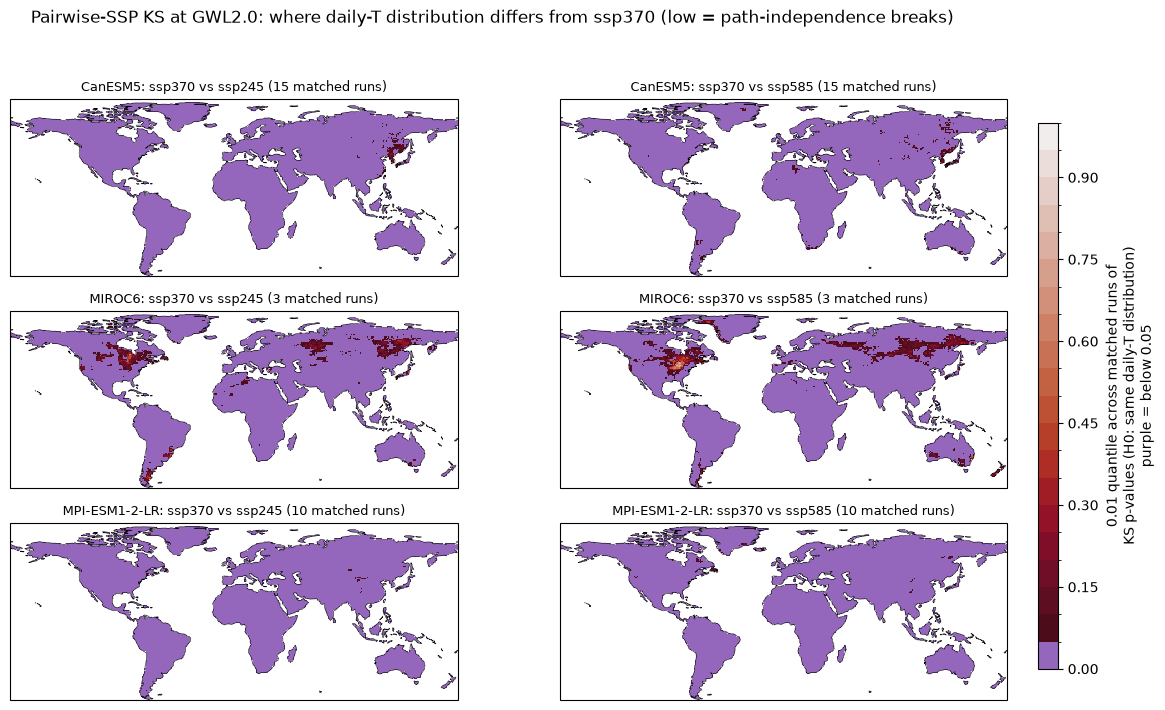

In [8]:
# Plot: rows = models, cols = comparisons. Authors' style (diag_qdm): linear 0-1
# map of the 0.01 quantile of p across matched runs, land only.
# cmap_mod exactly as authors' diag_qdm: amp_r with bottom 5% -> tab:purple
# (flat purple band marks p<0.05 "rejected").
base_cmap = cmocean.cm.amp_r
_colors = base_cmap(np.linspace(0, 1, 256))
_colors[:int(0.05 * 256), :] = mpl.colors.to_rgba('tab:purple')
cmap_mod = mpl.colors.ListedColormap(_colors)

fig, axes = plt.subplots(len(MODELS), len(OTHERS), figsize=(13, 2.6*len(MODELS)),
                         subplot_kw={'projection': ccrs.PlateCarree()})
for r, mod in enumerate(MODELS):
    for c, other in enumerate(OTHERS):
        ax = axes[r, c]
        if (mod, other) not in results:
            ax.set_visible(False); continue
        q = q01[(mod, other)].where(landmask == 1)
        im = q.plot(ax=ax, transform=ccrs.PlateCarree(), vmin=0, vmax=1,
                    cmap=cmap_mod, levels=21, add_colorbar=False)
        n = results[(mod, other)].sizes['run']
        ax.coastlines(linewidth=0.4)
        ax.set_title(f'{mod}: {ANCHOR} vs {other} ({n} matched runs)', fontsize=9)
        ax.set_xlabel(''); ax.set_ylabel('')
fig.subplots_adjust(right=0.9)
cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cax,
             label='0.01 quantile across matched runs of\nKS p-values (H0: same daily-T distribution)\npurple = below 0.05')
fig.suptitle(f'Pairwise-SSP KS at GWL{GWL}: where daily-T distribution differs '
             f'from {ANCHOR} (low = path-independence breaks)', y=0.995, fontsize=12)
out_dir = dir_list['aux'] + '../figures/'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(out_dir + 'ks_pvalue_maps_ssp370_GWL2.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'ks_pvalue_maps_ssp370_GWL2.png')